In [89]:
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from tensorflow.keras.preprocessing import timeseries_dataset_from_array
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import GRU, LSTM, Dense, Dropout

In [4]:
PATH = Path('.').absolute()
data_dir = PATH / 'data'

SEED = 1984

In [5]:
df = pd.read_csv(data_dir / 'cleaned_weather.csv')
df['date'] = pd.to_datetime(df['date'])

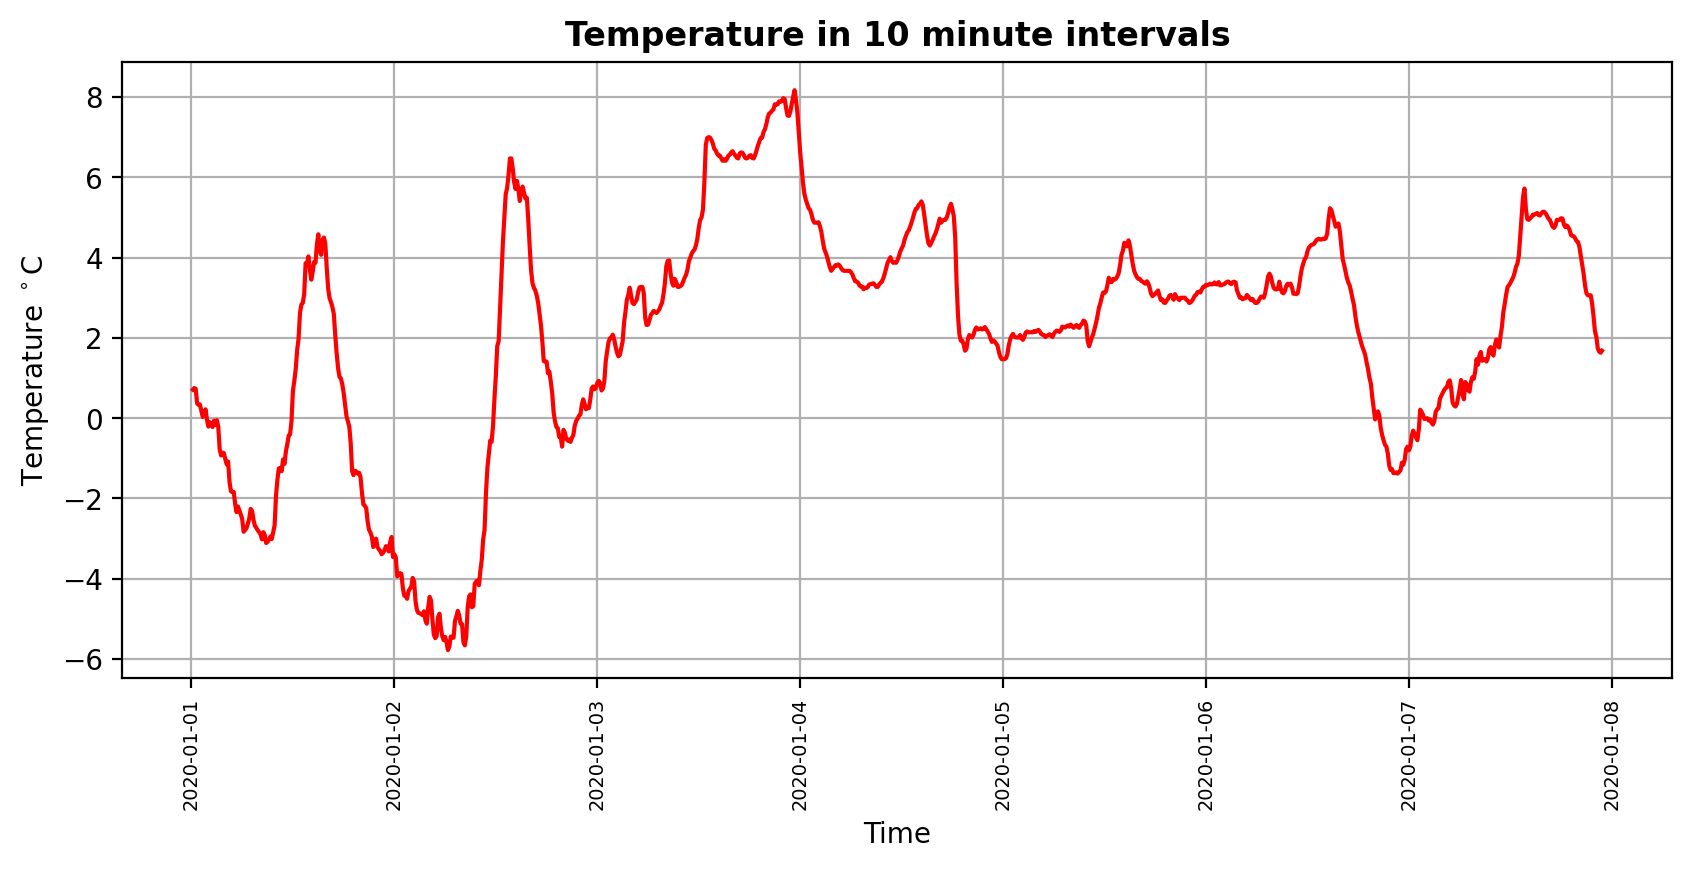

In [52]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=200)
ax.plot(df.loc[:1000, 'date'], df.loc[:1000, 'T'], color='red')
ax.tick_params(axis='x', labelrotation=90, labelsize='x-small')
ax.set_xlabel('Time')
ax.set_ylabel(r'Temperature $^\circ$C')
ax.set_title('Temperature in 10 minute intervals', fontweight='bold')
ax.grid(True)

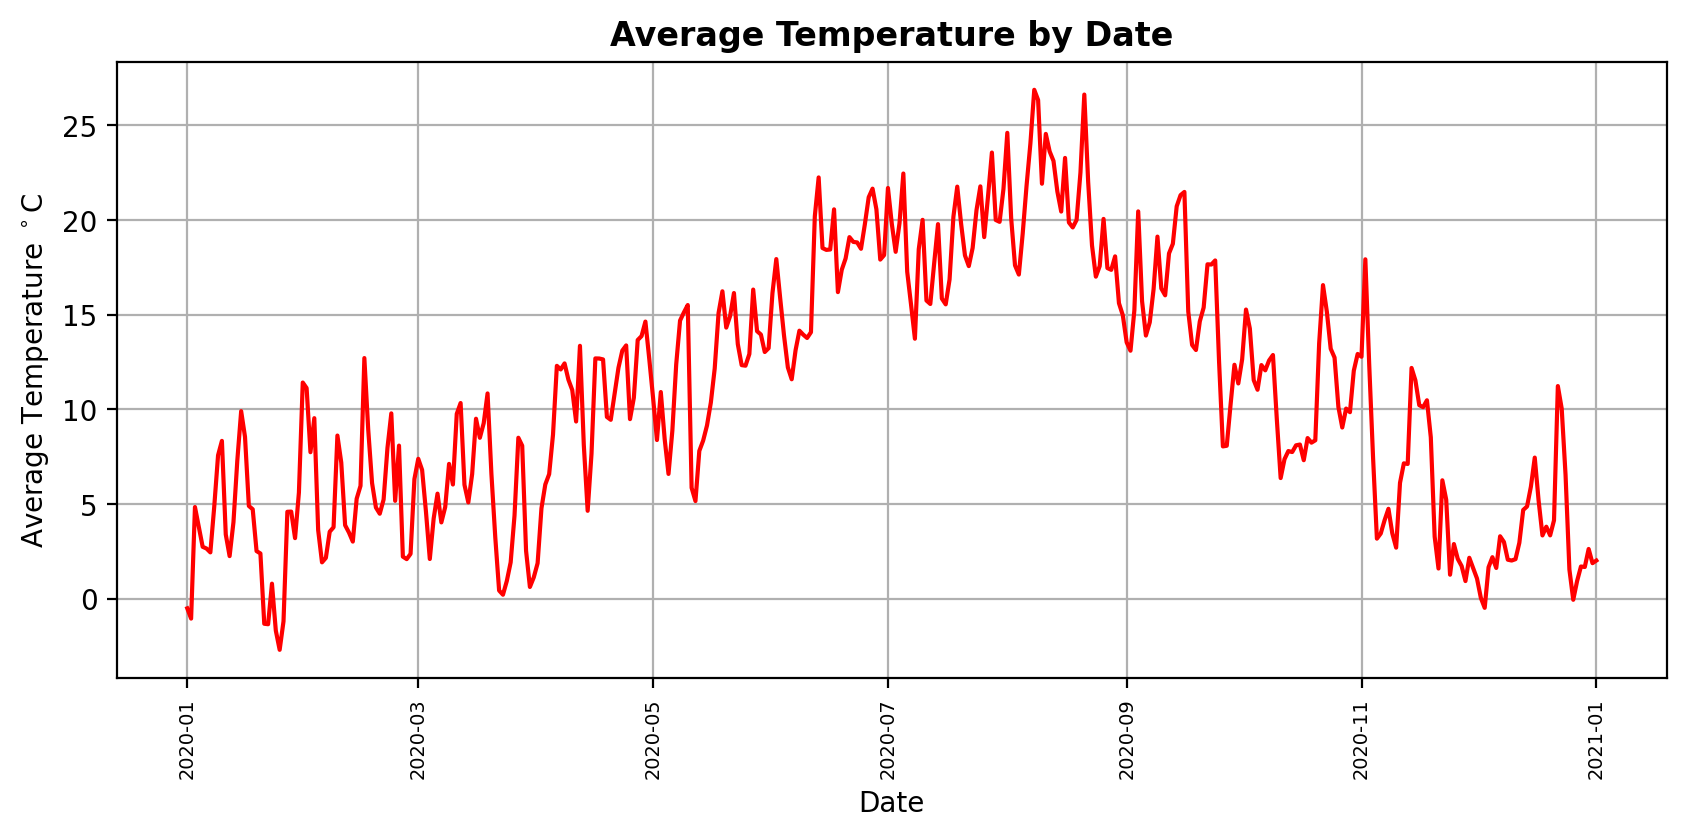

In [49]:
df['day'] = df['date'].dt.date

mean_T = df.groupby('day').mean()

fig, ax = plt.subplots(figsize=(10, 4), dpi=200)
ax.plot(mean_T.index, mean_T['T'], color='red')
ax.tick_params(axis='x', labelrotation=90, labelsize='x-small')
ax.set_xlabel('Date')
ax.set_ylabel(r'Average Temperature $^\circ$C')
ax.set_title('Average Temperature by Date', fontweight='bold')
ax.grid(True)

In [ ]:
def scale_dataset(df):
    # scale the data
    min_df = df.min(axis=0).to_numpy()
    max_df = df.max(axis=0).to_numpy()
    df = pd.DataFrame( 
        (df.to_numpy() - min_df) / (max_df - min_df), 
        columns=df.columns 
    )

    return df

def generate_data(df, train_percentage, valid_percentage):
    # set training and validation cutoff times
    num_records = df.shape[0]
    train_stop = int(num_records * train_percentage)
    valid_stop = int(num_records * valid_percentage) + train_stop

    inputs  = df.drop(columns=['date', 'T']).to_numpy(dtype=np.float32)
    targets = df['T'].to_numpy(dtype=np.float32)

    return train_stop, valid_stop, inputs, targets

In [68]:
train_percent = 0.5
valid_percent = 0.25
scaled_df = scale_dataset(df)
train_stop, valid_stop, inputs, targets = generate_data(scaled_df, train_percent, valid_percent)

SAMPLE_RATE = 6
WINDOW = 120
DELAY = SAMPLE_RATE * (WINDOW + 24 - 1)
BATCH_SIZE = 256

In [71]:
X_train = timeseries_dataset_from_array(
    inputs[:-DELAY],
    targets[DELAY:],
    WINDOW,
    sequence_stride=1,
    sampling_rate=SAMPLE_RATE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    start_index=0,
    end_index=train_stop
)

X_valid = timeseries_dataset_from_array(
    inputs[:-DELAY],
    targets[DELAY:],
    WINDOW,
    sequence_stride=1,
    sampling_rate=SAMPLE_RATE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    start_index=train_stop,
    end_index=valid_stop
)

X_test = timeseries_dataset_from_array(
    inputs[:-DELAY],
    targets[DELAY:],
    WINDOW,
    sequence_stride=1,
    sampling_rate=SAMPLE_RATE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    start_index=valid_stop,
    end_index=None
)

## Mimicking the basic example from Chollet

In [ ]:
inputs = Input(shape=(WINDOW, inputs.shape[-1]))
x = LSTM(16)(inputs)
outputs = Dense(1)(x)
model = Model(inputs, outputs)

model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

history = model.fit(X_train,
                    epochs=10,
                    validation_data=X_valid)

print(f'Test MAE: {model.evaluate(X_test)[1]:.2f}')

Epoch 1/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.1841 - mae: 0.2708 - val_loss: 0.0094 - val_mae: 0.0766
Epoch 2/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0070 - mae: 0.0660 - val_loss: 0.0086 - val_mae: 0.0722
Epoch 3/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0069 - mae: 0.0648 - val_loss: 0.0104 - val_mae: 0.0807
Epoch 4/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0067 - mae: 0.0641 - val_loss: 0.0086 - val_mae: 0.0721
Epoch 5/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0065 - mae: 0.0631 - val_loss: 0.0093 - val_mae: 0.0769
Epoch 6/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0065 - mae: 0.0632 - val_loss: 0.0080 - val_mae: 0.0687
Epoch 7/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0065 - mae: 0.0629 - val_loss: 0.0083 - val_mae: 0.0708
Epoch 8/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0064 - mae: 0.0623 - val_loss: 0.0081 - val_mae: 0.0697
Epoch 9/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/

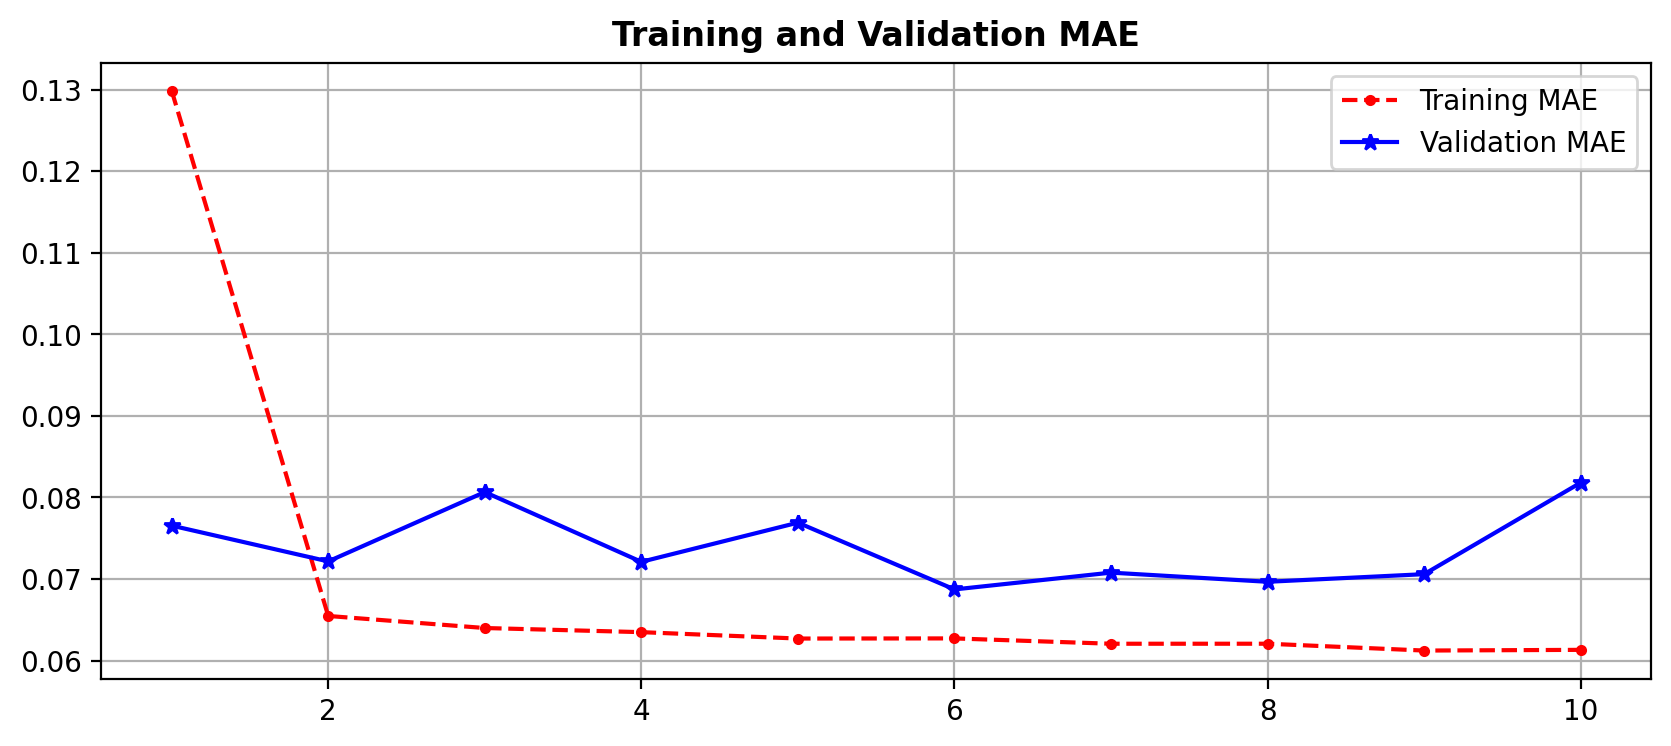

In [86]:
train_loss = history.history['mae']
valid_loss = history.history['val_mae']
epochs = range(1, len(train_loss) + 1)
fig, ax = plt.subplots(figsize=(10, 4), dpi=200)
ax.plot(epochs, train_loss, color='red',  linestyle='dashed', marker='.', label='Training MAE')
ax.plot(epochs, valid_loss, color='blue', linestyle='solid',  marker='*', label='Validation MAE')
ax.set_title("Training and Validation MAE", fontweight='bold')
ax.grid(True)
ax.legend();

## Change the optimizer to adam

In [ ]:
inputs = Input(shape=(WINDOW, inputs.shape[-1]))
x = LSTM(16)(inputs)
outputs = Dense(1)(x)
model = Model(inputs, outputs)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(X_train,
                    epochs=10,
                    validation_data=X_valid)

print(f'Test MAE: {model.evaluate(X_test)[1]:.2f}')

Epoch 1/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0470 - mae: 0.1607 - val_loss: 0.0078 - val_mae: 0.0700
Epoch 2/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0070 - mae: 0.0652 - val_loss: 0.0075 - val_mae: 0.0685
Epoch 3/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0068 - mae: 0.0645 - val_loss: 0.0074 - val_mae: 0.0679
Epoch 4/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0065 - mae: 0.0631 - val_loss: 0.0076 - val_mae: 0.0690
Epoch 5/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0062 - mae: 0.0614 - val_loss: 0.0076 - val_mae: 0.0688
Epoch 6/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0059 - mae: 0.0595 - val_loss: 0.0079 - val_mae: 0.0705
Epoch 7/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0056 - mae: 0.0583 - val_loss: 0.0078 - val_mae: 0.0700
Epoch 8/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0058 - mae: 0.0588 - val_loss: 0.0081 - val_mae: 0.0720
Epoch 9/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/

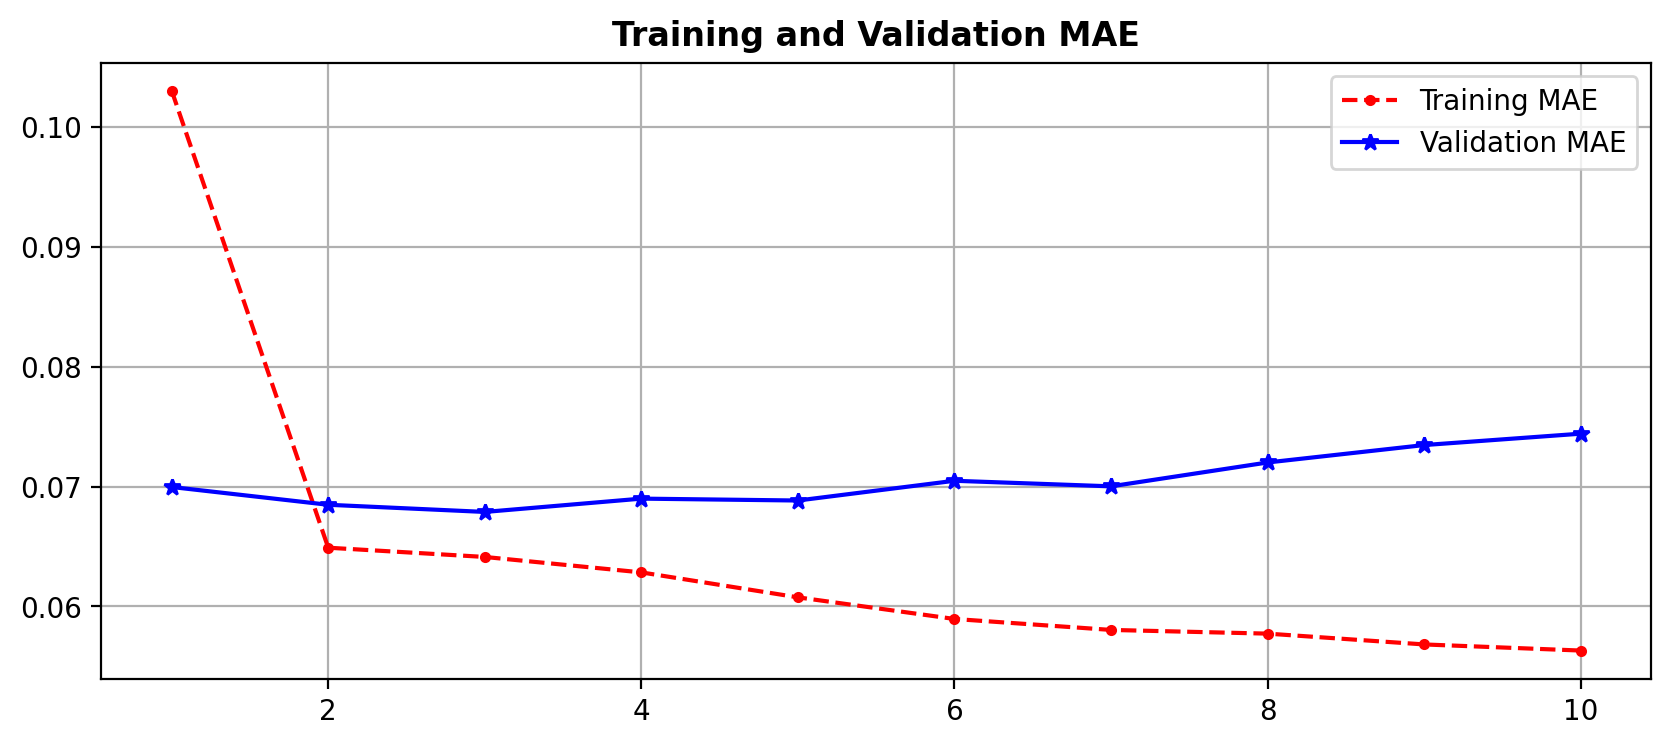

In [88]:
train_loss = history.history['mae']
valid_loss = history.history['val_mae']
epochs = range(1, len(train_loss) + 1)
fig, ax = plt.subplots(figsize=(10, 4), dpi=200)
ax.plot(epochs, train_loss, color='red',  linestyle='dashed', marker='.', label='Training MAE')
ax.plot(epochs, valid_loss, color='blue', linestyle='solid',  marker='*', label='Validation MAE')
ax.set_title("Training and Validation MAE", fontweight='bold')
ax.grid(True)
ax.legend();

## Mimicking Chollet example using dropout and more epochs

In [ ]:
inputs = Input(shape=(WINDOW, inputs.shape[-1]))
x = LSTM(32, recurrent_dropout=0.25)(inputs)
x = Dropout(0.5)(x)
outputs = Dense(1)(x)
model = Model(inputs, outputs)

model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

history = model.fit(X_train,
                    epochs=50,
                    validation_data=X_valid)

print(f'Test MAE: {model.evaluate(X_test)[1]:.2f}')

In [ ]:
train_loss = history.history['mae']
valid_loss = history.history['val_mae']
epochs = range(1, len(train_loss) + 1)
fig, ax = plt.subplots(figsize=(10, 4), dpi=200)
ax.plot(epochs, train_loss, color='red',  linestyle='dashed', marker='.', label='Training MAE')
ax.plot(epochs, valid_loss, color='blue', linestyle='solid',  marker='*', label='Validation MAE')
ax.set_title("Training and Validation MAE", fontweight='bold')
ax.grid(True)
ax.legend();